<a href="https://colab.research.google.com/github/kyokux2/Laboratorio3token/blob/main/CharTokenization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch numpy matplotlib tqdm requests

In [2]:
import os
import math
import time
import random
import requests
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from tqdm import tqdm

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [4]:
url = "https://www.gutenberg.org/files/11/11-0.txt"
path = "input.txt"

if not os.path.exists(path):
    response = requests.get(url)
    response.raise_for_status()

    with open(path, "w", encoding="utf-8") as f:
        f.write(response.text)

with open(path, "r", encoding="utf-8") as f:
    text = f.read()

print("Longitud del texto:", len(text))
print(text[:1000])

Longitud del texto: 144696
*** START OF THE PROJECT GUTENBERG EBOOK 11 ***

[Illustration]




Alice’s Adventures in Wonderland

by Lewis Carroll

THE MILLENNIUM FULCRUM EDITION 3.0

Contents

 CHAPTER I.     Down the Rabbit-Hole
 CHAPTER II.    The Pool of Tears
 CHAPTER III.   A Caucus-Race and a Long Tale
 CHAPTER IV.    The Rabbit Sends in a Little Bill
 CHAPTER V.     Advice from a Caterpillar
 CHAPTER VI.    Pig and Pepper
 CHAPTER VII.   A Mad Tea-Party
 CHAPTER VIII.  The Queen’s Croquet-Ground
 CHAPTER IX.    The Mock Turtle’s Story
 CHAPTER X.     The Lobster Quadrille
 CHAPTER XI.    Who Stole the Tarts?
 CHAPTER XII.   Alice’s Evidence




CHAPTER I.
Down the Rabbit-Hole


Alice was beginning to get very tired of sitting by her sister on the
bank, and of having nothing to do: once or twice she had peeped into
the book her sister was reading, but it had no pictures or
conversations in it, “and what is the use of a book,” thought Alice
“without pictures or conversations?”

So

In [5]:
text = text.lower()

start_marker = "*** start of the project gutenberg ebook"
end_marker = "*** end of the project gutenberg ebook"

start_idx = text.find(start_marker)
end_idx = text.find(end_marker)

if start_idx != -1:
    text = text[start_idx:]

if end_idx != -1:
    text = text[:end_idx]

print("Longitud después de limpieza:", len(text))
print(text[:1000])

Longitud después de limpieza: 144650
*** start of the project gutenberg ebook 11 ***

[illustration]




alice’s adventures in wonderland

by lewis carroll

the millennium fulcrum edition 3.0

contents

 chapter i.     down the rabbit-hole
 chapter ii.    the pool of tears
 chapter iii.   a caucus-race and a long tale
 chapter iv.    the rabbit sends in a little bill
 chapter v.     advice from a caterpillar
 chapter vi.    pig and pepper
 chapter vii.   a mad tea-party
 chapter viii.  the queen’s croquet-ground
 chapter ix.    the mock turtle’s story
 chapter x.     the lobster quadrille
 chapter xi.    who stole the tarts?
 chapter xii.   alice’s evidence




chapter i.
down the rabbit-hole


alice was beginning to get very tired of sitting by her sister on the
bank, and of having nothing to do: once or twice she had peeped into
the book her sister was reading, but it had no pictures or
conversations in it, “and what is the use of a book,” thought alice
“without pictures or conversat

In [6]:
chars = sorted(list(set(text)))
vocab_size = len(chars)

stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}

def encode(s):
    return [stoi[c] for c in s]

def decode(ids):
    return "".join([itos[i] for i in ids])

print("Tamaño del vocabulario:", vocab_size)
print(chars)

Tamaño del vocabulario: 50
['\n', ' ', '!', '(', ')', '*', ',', '-', '.', '0', '1', '3', ':', ';', '?', '[', ']', '_', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', 'ù', '—', '‘', '’', '“', '”']


In [7]:
data = torch.tensor(encode(text), dtype=torch.long)

train_size = int(0.9 * len(data))
train_data = data[:train_size]
val_data = data[train_size:]

block_size = 128
batch_size = 64

def get_batch(split):
    source = train_data if split == "train" else val_data

    ix = torch.randint(len(source) - block_size - 1, (batch_size,))

    x = torch.stack([source[i:i+block_size] for i in ix])
    y = torch.stack([source[i+1:i+block_size+1] for i in ix])

    x = x.to(device)
    y = y.to(device)

    return x, y

x, y = get_batch("train")

print(x.shape)
print(y.shape)
print(decode(x[0].tolist()))
print("---- TARGET ----")
print(decode(y[0].tolist()))

torch.Size([64, 128])
torch.Size([64, 128])
ad felt quite unhappy at the
number of executions the queen had ordered.

they very soon came upon a gryphon, lying fast asleep 
---- TARGET ----
d felt quite unhappy at the
number of executions the queen had ordered.

they very soon came upon a gryphon, lying fast asleep i


In [8]:
@torch.no_grad()
def estimate_loss(model, eval_iters=50):
    results = {}

    model.eval()

    for split in ["train", "val"]:
        losses = torch.zeros(eval_iters)

        for k in range(eval_iters):
            x, y = get_batch(split)
            logits, loss = model(x, y)
            losses[k] = loss.item()

        results[split] = losses.mean().item()

    model.train()
    return results

In [9]:
def train_model(model, model_name, max_iters=1000, eval_interval=200, learning_rate=3e-4):
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

    history = {
        "model": [],
        "iter": [],
        "train_loss": [],
        "val_loss": [],
        "train_perplexity": [],
        "val_perplexity": []
    }

    model.train()

    for iteration in range(max_iters + 1):

        if iteration % eval_interval == 0:
            losses = estimate_loss(model)

            train_loss = losses["train"]
            val_loss = losses["val"]

            train_ppl = math.exp(train_loss)
            val_ppl = math.exp(val_loss)

            history["model"].append(model_name)
            history["iter"].append(iteration)
            history["train_loss"].append(train_loss)
            history["val_loss"].append(val_loss)
            history["train_perplexity"].append(train_ppl)
            history["val_perplexity"].append(val_ppl)

            print(
                f"{model_name} | iter {iteration}: "
                f"train loss {train_loss:.4f}, val loss {val_loss:.4f}, "
                f"train ppl {train_ppl:.2f}, val ppl {val_ppl:.2f}"
            )

        x, y = get_batch("train")

        logits, loss = model(x, y)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

    return history

In [10]:
class SimpleRNNLanguageModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=256, num_layers=1):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        self.rnn = nn.RNN(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, idx, targets=None):
        x = self.embedding(idx)

        output, hidden = self.rnn(x)

        logits = self.fc(output)

        loss = None

        if targets is not None:
            batch_size, seq_len, vocab_size_local = logits.shape

            logits_flat = logits.view(batch_size * seq_len, vocab_size_local)
            targets_flat = targets.view(batch_size * seq_len)

            loss = F.cross_entropy(logits_flat, targets_flat)

        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens=300, temperature=1.0):
        self.eval()

        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]

            logits, loss = self(idx_cond)

            logits = logits[:, -1, :] / temperature

            probs = F.softmax(logits, dim=-1)

            idx_next = torch.multinomial(probs, num_samples=1)

            idx = torch.cat((idx, idx_next), dim=1)

        self.train()

        return idx

In [11]:
simple_rnn = SimpleRNNLanguageModel(
    vocab_size=vocab_size,
    embedding_dim=128,
    hidden_dim=256,
    num_layers=1
).to(device)

print("Número de parámetros:", sum(p.numel() for p in simple_rnn.parameters()))

history_simple_rnn = train_model(
    model=simple_rnn,
    model_name="Simple RNN",
    max_iters=1000,
    eval_interval=200,
    learning_rate=3e-4
)

Número de parámetros: 118066
Simple RNN | iter 0: train loss 3.9476, val loss 3.9495, train ppl 51.81, val ppl 51.91
Simple RNN | iter 200: train loss 2.1029, val loss 2.1041, train ppl 8.19, val ppl 8.20
Simple RNN | iter 400: train loss 1.8412, val loss 1.8735, train ppl 6.30, val ppl 6.51
Simple RNN | iter 600: train loss 1.6835, val loss 1.7411, train ppl 5.38, val ppl 5.70
Simple RNN | iter 800: train loss 1.5692, val loss 1.6565, train ppl 4.80, val ppl 5.24
Simple RNN | iter 1000: train loss 1.4886, val loss 1.6018, train ppl 4.43, val ppl 4.96


In [12]:
context = torch.zeros((1, 1), dtype=torch.long, device=device)

generated_ids = simple_rnn.generate(
    context,
    max_new_tokens=500,
    temperature=0.8
)

generated_text_simple_rnn = decode(generated_ids[0].tolist())

print(generated_text_simple_rnn)


you’ll cassaid the minuse, and alice handed one,
and begs, that after her which wat to the cat, trem, and if ye
to see some it and in a stone.

“crcats, i shall said too makch. anither one, word all mock turtle down it had alice cas mack: “how the foon a lit?” said, and raid to sighoning of my dearghted off with realy you, amchise lest at about the mort the mocketed of it’s the
ead up the low
only it agained to betting to not!”

“he lough as me alice down, and down a rig?” for herself brought as


In [13]:
generated_samples = {}

generated_samples["Simple RNN"] = generated_text_simple_rnn

print(generated_samples["Simple RNN"])


you’ll cassaid the minuse, and alice handed one,
and begs, that after her which wat to the cat, trem, and if ye
to see some it and in a stone.

“crcats, i shall said too makch. anither one, word all mock turtle down it had alice cas mack: “how the foon a lit?” said, and raid to sighoning of my dearghted off with realy you, amchise lest at about the mort the mocketed of it’s the
ead up the low
only it agained to betting to not!”

“he lough as me alice down, and down a rig?” for herself brought as


In [14]:
class LSTMLanguageModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=256, num_layers=1, bidirectional=False):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional
        )

        direction_factor = 2 if bidirectional else 1

        self.fc = nn.Linear(hidden_dim * direction_factor, vocab_size)

    def forward(self, idx, targets=None):
        x = self.embedding(idx)

        output, hidden = self.lstm(x)

        logits = self.fc(output)

        loss = None

        if targets is not None:
            batch_size, seq_len, vocab_size_local = logits.shape

            logits_flat = logits.view(batch_size * seq_len, vocab_size_local)
            targets_flat = targets.view(batch_size * seq_len)

            loss = F.cross_entropy(logits_flat, targets_flat)

        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens=300, temperature=1.0):
        self.eval()

        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]

            logits, loss = self(idx_cond)

            logits = logits[:, -1, :] / temperature

            probs = F.softmax(logits, dim=-1)

            idx_next = torch.multinomial(probs, num_samples=1)

            idx = torch.cat((idx, idx_next), dim=1)

        self.train()

        return idx

In [15]:
lstm_1_layer = LSTMLanguageModel(
    vocab_size=vocab_size,
    embedding_dim=128,
    hidden_dim=256,
    num_layers=1,
    bidirectional=False
).to(device)

print("Número de parámetros:", sum(p.numel() for p in lstm_1_layer.parameters()))

history_lstm_1_layer = train_model(
    model=lstm_1_layer,
    model_name="LSTM 1 layer",
    max_iters=1000,
    eval_interval=200,
    learning_rate=3e-4
)

Número de parámetros: 414514
LSTM 1 layer | iter 0: train loss 3.9180, val loss 3.9190, train ppl 50.30, val ppl 50.35
LSTM 1 layer | iter 200: train loss 2.2041, val loss 2.2065, train ppl 9.06, val ppl 9.08
LSTM 1 layer | iter 400: train loss 1.8908, val loss 1.9169, train ppl 6.62, val ppl 6.80
LSTM 1 layer | iter 600: train loss 1.7289, val loss 1.7691, train ppl 5.63, val ppl 5.87
LSTM 1 layer | iter 800: train loss 1.6120, val loss 1.6834, train ppl 5.01, val ppl 5.38
LSTM 1 layer | iter 1000: train loss 1.5261, val loss 1.6177, train ppl 4.60, val ppl 5.04


In [16]:
context = torch.zeros((1, 1), dtype=torch.long, device=device)

generated_ids = lstm_1_layer.generate(
    context,
    max_new_tokens=500,
    temperature=0.8
)

generated_text_lstm_1_layer = decode(generated_ids[0].tolist())

print(generated_text_lstm_1_layer)


there ardry soide_ you makend to be the could a low!” a
tone doot op the other to the welln again—i
come the moch very were see of your peresn’t one were like to a belingl and story to tem_ a little souse awital had out think out you dreat!” said the when it up to the way
stoond of earthing in the mock to know i detter near her again.

“i haven had to hery tuck to the went in
had not for began it ond to see the urtily; she
little again.

“the!”

“down wisther you had,” said the dormesss a slook 


In [17]:
generated_samples["LSTM 1 layer"] = generated_text_lstm_1_layer

print(generated_samples["LSTM 1 layer"])


there ardry soide_ you makend to be the could a low!” a
tone doot op the other to the welln again—i
come the moch very were see of your peresn’t one were like to a belingl and story to tem_ a little souse awital had out think out you dreat!” said the when it up to the way
stoond of earthing in the mock to know i detter near her again.

“i haven had to hery tuck to the went in
had not for began it ond to see the urtily; she
little again.

“the!”

“down wisther you had,” said the dormesss a slook 


In [18]:
lstm_multi_layer = LSTMLanguageModel(
    vocab_size=vocab_size,
    embedding_dim=128,
    hidden_dim=256,
    num_layers=2,
    bidirectional=False
).to(device)

print("Número de parámetros:", sum(p.numel() for p in lstm_multi_layer.parameters()))

history_lstm_multi_layer = train_model(
    model=lstm_multi_layer,
    model_name="LSTM multi layer",
    max_iters=1000,
    eval_interval=200,
    learning_rate=3e-4
)

Número de parámetros: 940850
LSTM multi layer | iter 0: train loss 3.8869, val loss 3.8874, train ppl 48.76, val ppl 48.79
LSTM multi layer | iter 200: train loss 2.2708, val loss 2.2729, train ppl 9.69, val ppl 9.71
LSTM multi layer | iter 400: train loss 1.8971, val loss 1.9183, train ppl 6.67, val ppl 6.81
LSTM multi layer | iter 600: train loss 1.6833, val loss 1.7444, train ppl 5.38, val ppl 5.72
LSTM multi layer | iter 800: train loss 1.5405, val loss 1.6369, train ppl 4.67, val ppl 5.14
LSTM multi layer | iter 1000: train loss 1.4330, val loss 1.5663, train ppl 4.19, val ppl 4.79


In [19]:
context = torch.zeros((1, 1), dtype=torch.long, device=device)

generated_ids = lstm_multi_layer.generate(
    context,
    max_new_tokens=500,
    temperature=0.8
)

generated_text_lstm_multi_layer = decode(generated_ids[0].tolist())

print(generated_text_lstm_multi_layer)



the rrabting turrily and so she knows as me with the
sure all squeen a lick to turtles was viyed on
alise that least back alice cried; “then, the roppots it was, think i havany was words in what a_ the whise in in she was not a little greht-will,” said the hatting spepent of the
caust for the beardy, chacking, and with long alice, it said went herself, and she said to said to a more a clast,
alice had to get at the forman, in the pite a least wish, thage to see the mopled as one, think itsey yo


In [20]:
generated_samples["LSTM multi layer"] = generated_text_lstm_multi_layer

print(generated_samples["LSTM multi layer"])



the rrabting turrily and so she knows as me with the
sure all squeen a lick to turtles was viyed on
alise that least back alice cried; “then, the roppots it was, think i havany was words in what a_ the whise in in she was not a little greht-will,” said the hatting spepent of the
caust for the beardy, chacking, and with long alice, it said went herself, and she said to said to a more a clast,
alice had to get at the forman, in the pite a least wish, thage to see the mopled as one, think itsey yo


In [21]:
all_histories = []

all_histories.extend([
    history_simple_rnn,
    history_lstm_1_layer,
    history_lstm_multi_layer
])

print("Historiales guardados:", len(all_histories))

Historiales guardados: 3


In [22]:
bilstm = LSTMLanguageModel(
    vocab_size=vocab_size,
    embedding_dim=128,
    hidden_dim=256,
    num_layers=1,
    bidirectional=True
).to(device)

print("Número de parámetros:", sum(p.numel() for p in bilstm.parameters()))

history_bilstm = train_model(
    model=bilstm,
    model_name="Bidirectional LSTM",
    max_iters=1000,
    eval_interval=200,
    learning_rate=3e-4
)

Número de parámetros: 822578
Bidirectional LSTM | iter 0: train loss 3.9012, val loss 3.9025, train ppl 49.46, val ppl 49.52
Bidirectional LSTM | iter 200: train loss 0.2000, val loss 0.2115, train ppl 1.22, val ppl 1.24
Bidirectional LSTM | iter 400: train loss 0.0523, val loss 0.0568, train ppl 1.05, val ppl 1.06
Bidirectional LSTM | iter 600: train loss 0.0306, val loss 0.0326, train ppl 1.03, val ppl 1.03
Bidirectional LSTM | iter 800: train loss 0.0244, val loss 0.0252, train ppl 1.02, val ppl 1.03
Bidirectional LSTM | iter 1000: train loss 0.0212, val loss 0.0217, train ppl 1.02, val ppl 1.02


In [23]:
context = torch.zeros((1, 1), dtype=torch.long, device=device)

generated_ids = bilstm.generate(
    context,
    max_new_tokens=500,
    temperature=0.8
)

generated_text_bilstm = decode(generated_ids[0].tolist())

print(generated_text_bilstm)



eassidirkd to sa w car shand ill freezling searis quse nout hthe hhat am” then are ster,tou newan_ cous smow!” hen, wat on lithe sorh ‘ie  leam in the the pit to ly busaid aw.

“or kout the lovep and she sawepi dof at in all, insthe-dalt ali, the aic)s and alice santccit an the and the

finnd ward exalit, *ohan_, theme_. noug,” ckit ulice tho wabut--oug;e_.

“swalli gly she matheg)))
thocartb,
wer che,  onit?se ted tthat nother in y rtiltly the unlin ale sit ang ther as woudrra thimva)lind and 


In [24]:
generated_samples["Bidirectional LSTM"] = generated_text_bilstm

print(generated_samples["Bidirectional LSTM"])



eassidirkd to sa w car shand ill freezling searis quse nout hthe hhat am” then are ster,tou newan_ cous smow!” hen, wat on lithe sorh ‘ie  leam in the the pit to ly busaid aw.

“or kout the lovep and she sawepi dof at in all, insthe-dalt ali, the aic)s and alice santccit an the and the

finnd ward exalit, *ohan_, theme_. noug,” ckit ulice tho wabut--oug;e_.

“swalli gly she matheg)))
thocartb,
wer che,  onit?se ted tthat nother in y rtiltly the unlin ale sit ang ther as woudrra thimva)lind and 


In [25]:
all_histories = []

all_histories.extend([
    history_simple_rnn,
    history_lstm_1_layer,
    history_lstm_multi_layer,
    history_bilstm
])

print("Historiales guardados:", len(all_histories))

Historiales guardados: 4


In [26]:
import pandas as pd

rows = []

for history in all_histories:
    final_index = -1

    rows.append({
        "model": history["model"][final_index],
        "final_iter": history["iter"][final_index],
        "train_loss": history["train_loss"][final_index],
        "val_loss": history["val_loss"][final_index],
        "train_perplexity": history["train_perplexity"][final_index],
        "val_perplexity": history["val_perplexity"][final_index],
    })

results_df = pd.DataFrame(rows)
results_df

,model,final_iter,train_loss,val_loss,train_perplexity,val_perplexity
0,Simple RNN,1000,1.488566,1.601809,4.430736,4.962000
1,LSTM 1 layer,1000,1.526054,1.617714,4.599991,5.041550
2,LSTM multi layer,1000,1.433001,1.566251,4.191260,4.788661
3,Bidirectional LSTM,1000,0.021221,0.021672,1.021448,1.021908


In [27]:
class Head(nn.Module):
    def __init__(self, head_size, n_embd, block_size, dropout=0.2):
        super().__init__()

        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)

        self.register_buffer(
            "tril",
            torch.tril(torch.ones(block_size, block_size))
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        batch_size, seq_len, channels = x.shape

        k = self.key(x)
        q = self.query(x)

        weights = q @ k.transpose(-2, -1) * channels ** -0.5
        weights = weights.masked_fill(
            self.tril[:seq_len, :seq_len] == 0,
            float("-inf")
        )

        weights = F.softmax(weights, dim=-1)
        weights = self.dropout(weights)

        v = self.value(x)
        output = weights @ v

        return output


class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size, n_embd, block_size, dropout=0.2):
        super().__init__()

        self.heads = nn.ModuleList([
            Head(head_size, n_embd, block_size, dropout)
            for _ in range(num_heads)
        ])

        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        output = torch.cat([head(x) for head in self.heads], dim=-1)
        output = self.proj(output)
        output = self.dropout(output)

        return output


class FeedForward(nn.Module):
    def __init__(self, n_embd, dropout=0.2):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)


class Block(nn.Module):
    def __init__(self, n_embd, n_head, block_size, dropout=0.2):
        super().__init__()

        head_size = n_embd // n_head

        self.self_attention = MultiHeadAttention(
            num_heads=n_head,
            head_size=head_size,
            n_embd=n_embd,
            block_size=block_size,
            dropout=dropout
        )

        self.feed_forward = FeedForward(n_embd, dropout)

        self.layer_norm_1 = nn.LayerNorm(n_embd)
        self.layer_norm_2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.self_attention(self.layer_norm_1(x))
        x = x + self.feed_forward(self.layer_norm_2(x))

        return x

In [28]:
class GPTLanguageModel(nn.Module):
    def __init__(
        self,
        vocab_size,
        block_size,
        n_embd=128,
        n_head=4,
        n_layer=4,
        dropout=0.2
    ):
        super().__init__()

        self.block_size = block_size

        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)

        self.blocks = nn.Sequential(*[
            Block(n_embd, n_head, block_size, dropout)
            for _ in range(n_layer)
        ])

        self.layer_norm_final = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        batch_size, seq_len = idx.shape

        token_embeddings = self.token_embedding_table(idx)

        positions = torch.arange(seq_len, device=idx.device)
        position_embeddings = self.position_embedding_table(positions)

        x = token_embeddings + position_embeddings

        x = self.blocks(x)
        x = self.layer_norm_final(x)

        logits = self.lm_head(x)

        loss = None

        if targets is not None:
            batch_size, seq_len, vocab_size_local = logits.shape

            logits_flat = logits.reshape(batch_size * seq_len, vocab_size_local)
            targets_flat = targets.reshape(batch_size * seq_len)

            loss = F.cross_entropy(logits_flat, targets_flat)

        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens=300, temperature=1.0):
        self.eval()

        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.block_size:]

            logits, loss = self(idx_cond)

            logits = logits[:, -1, :] / temperature

            probs = F.softmax(logits, dim=-1)

            idx_next = torch.multinomial(probs, num_samples=1)

            idx = torch.cat((idx, idx_next), dim=1)

        self.train()

        return idx

In [29]:
gpt_model = GPTLanguageModel(
    vocab_size=vocab_size,
    block_size=block_size,
    n_embd=128,
    n_head=4,
    n_layer=4,
    dropout=0.2
).to(device)

print("Número de parámetros:", sum(p.numel() for p in gpt_model.parameters()))

history_gpt = train_model(
    model=gpt_model,
    model_name="GPT from scratch",
    max_iters=1000,
    eval_interval=200,
    learning_rate=3e-4
)

Número de parámetros: 821042
GPT from scratch | iter 0: train loss 4.0526, val loss 4.0461, train ppl 57.55, val ppl 57.17
GPT from scratch | iter 200: train loss 2.4307, val loss 2.4269, train ppl 11.37, val ppl 11.32
GPT from scratch | iter 400: train loss 2.3450, val loss 2.3546, train ppl 10.43, val ppl 10.53
GPT from scratch | iter 600: train loss 2.2256, val loss 2.2301, train ppl 9.26, val ppl 9.30
GPT from scratch | iter 800: train loss 2.0302, val loss 2.0470, train ppl 7.62, val ppl 7.74
GPT from scratch | iter 1000: train loss 1.8820, val loss 1.9015, train ppl 6.57, val ppl 6.70


In [30]:
context = torch.zeros((1, 1), dtype=torch.long, device=device)

generated_ids = gpt_model.generate(
    context,
    max_new_tokens=500,
    temperature=0.8
)

generated_text_gpt = decode(generated_ids[0].tolist())

print(generated_text_gpt)


the soum therr say power ened this ir a came a to as colkiar firte he
poon hat the fhen ome the he by whant he to
conettell tinten. “she of cree to wall of up thas a muskent jury sown ard corked theilith ad the riom
of hat she s muse doow.

“the wis gothe ith know of thated exch felar whing ofthe ber on
the qurie me hing leeg graven the offur wover the the quild it groten the tome
wise castiolde clet of lat the he of thy a the shie udeereare
pould any we beevesookent ursmin and to turst was the 


In [31]:
generated_samples["GPT from scratch"] = generated_text_gpt

print(generated_samples["GPT from scratch"])


the soum therr say power ened this ir a came a to as colkiar firte he
poon hat the fhen ome the he by whant he to
conettell tinten. “she of cree to wall of up thas a muskent jury sown ard corked theilith ad the riom
of hat she s muse doow.

“the wis gothe ith know of thated exch felar whing ofthe ber on
the qurie me hing leeg graven the offur wover the the quild it groten the tome
wise castiolde clet of lat the he of thy a the shie udeereare
pould any we beevesookent ursmin and to turst was the 


In [32]:
all_histories = []

all_histories.extend([
    history_simple_rnn,
    history_lstm_1_layer,
    history_lstm_multi_layer,
    history_bilstm,
    history_gpt
])

rows = []

for history in all_histories:
    final_index = -1

    rows.append({
        "model": history["model"][final_index],
        "final_iter": history["iter"][final_index],
        "train_loss": history["train_loss"][final_index],
        "val_loss": history["val_loss"][final_index],
        "train_perplexity": history["train_perplexity"][final_index],
        "val_perplexity": history["val_perplexity"][final_index],
    })

results_df = pd.DataFrame(rows)
results_df

,model,final_iter,train_loss,val_loss,train_perplexity,val_perplexity
0,Simple RNN,1000,1.488566,1.601809,4.430736,4.962000
1,LSTM 1 layer,1000,1.526054,1.617714,4.599991,5.041550
2,LSTM multi layer,1000,1.433001,1.566251,4.191260,4.788661
3,Bidirectional LSTM,1000,0.021221,0.021672,1.021448,1.021908
4,GPT from scratch,1000,1.882018,1.901541,6.566742,6.696207


In [33]:
results_df.to_csv("char_tokenization_results.csv", index=False)

print("Resultados guardados en char_tokenization_results.csv")

Resultados guardados en char_tokenization_results.csv


In [34]:
for model_name, sample_text in generated_samples.items():
    print("=" * 80)
    print(model_name)
    print("=" * 80)
    print(sample_text[:1000])
    print()

Simple RNN

you’ll cassaid the minuse, and alice handed one,
and begs, that after her which wat to the cat, trem, and if ye
to see some it and in a stone.

“crcats, i shall said too makch. anither one, word all mock turtle down it had alice cas mack: “how the foon a lit?” said, and raid to sighoning of my dearghted off with realy you, amchise lest at about the mort the mocketed of it’s the
ead up the low
only it agained to betting to not!”

“he lough as me alice down, and down a rig?” for herself brought as

LSTM 1 layer

there ardry soide_ you makend to be the could a low!” a
tone doot op the other to the welln again—i
come the moch very were see of your peresn’t one were like to a belingl and story to tem_ a little souse awital had out think out you dreat!” said the when it up to the way
stoond of earthing in the mock to know i detter near her again.

“i haven had to hery tuck to the went in
had not for began it ond to see the urtily; she
little again.

“the!”

“down wisther you had,

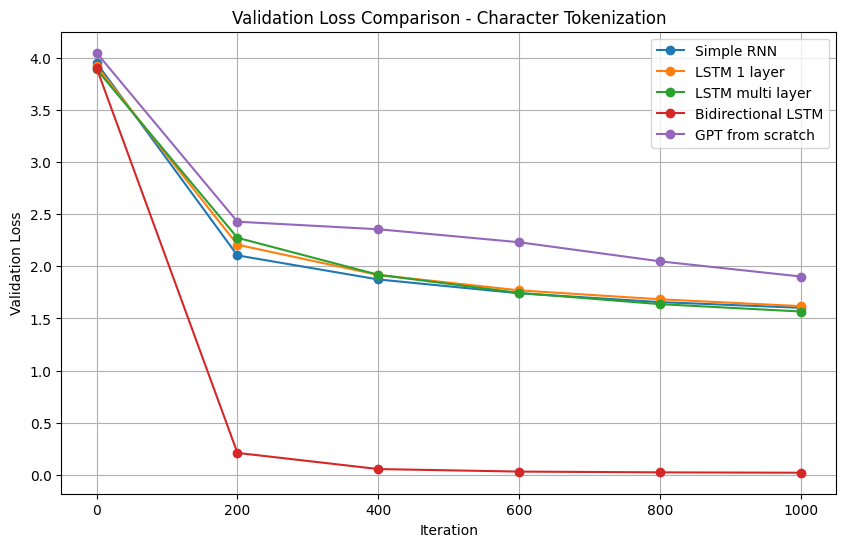

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for history in all_histories:
    plt.plot(
        history["iter"],
        history["val_loss"],
        marker="o",
        label=history["model"][-1]
    )

plt.xlabel("Iteration")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison - Character Tokenization")
plt.legend()
plt.grid(True)
plt.show()